# Análisis exploratorio mínimo (EDA) — UNSW-NB15

Este notebook revisa la forma, integridad y distribución de los archivos oficiales de entrenamiento y prueba. Las descripciones de variables, distribuciones, categorías y controles de relación se calculan por separado para cada partición. Las observaciones que puedan orientar decisiones de modelado (en particular, el cruce de `sttl` con `label`) se hacen únicamente sobre train. El test se inspecciona solo para comprobar los datos.

Los CSV de `data/raw/` se leen sin modificarlos. Antes de cargarlos se verifica su MD5 contra los valores documentados en `data/README.md`.


In [13]:
import sys
sys.path.append("..")

import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from src.config import (
    TRAIN_CSV,
    TEST_CSV,
    CATEGORICAL_COLS,
    BINARY_TARGET,
    MULTICLASS_TARGET,
    ID_COL,
    EXPECTED_MD5,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 60)


## Carga y verificación de integridad

Se comprueban los hashes oficiales y luego se cargan ambos CSV.

In [14]:
def md5_file(path: Path) -> str:
    digest = hashlib.md5()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

for csv_path in (TRAIN_CSV, TEST_CSV):
    if not csv_path.is_file():
        raise FileNotFoundError(
            f"No se encontró {csv_path}. Descargá los CSV oficiales y ubicalos en data/raw/; "
            "consultá data/README.md."
        )
    actual_md5 = md5_file(csv_path)
    expected_md5 = EXPECTED_MD5[csv_path.name]
    print(f"{csv_path.name}: MD5 {actual_md5} — " + ("OK" if actual_md5 == expected_md5 else "NO COINCIDE"))
    if actual_md5 != expected_md5:
        raise ValueError(f"El MD5 de {csv_path.name} no coincide con data/README.md")

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
print("\nArchivos oficiales verificados y cargados.")


UNSW_NB15_training-set.csv: MD5 e55caabaa6cd4a8f1c06a227bcfababc — OK
UNSW_NB15_testing-set.csv: MD5 e0beea40262e46168cdb81476dbc27b4 — OK

Archivos oficiales verificados y cargados.


## Forma y tipos de las columnas

La forma se expresa como filas × columnas. Se muestran los tipos leídos por pandas para cada partición.

In [15]:
print(f"Train: {train_df.shape[0]:,} filas × {train_df.shape[1]} columnas")
print(train_df.dtypes.rename("dtype").to_string())
print(f"\nTest: {test_df.shape[0]:,} filas × {test_df.shape[1]} columnas")
print(test_df.dtypes.rename("dtype").to_string())


Train: 175,341 filas × 45 columnas
id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_l

## Valores nulos

Se informa el total de celdas nulas en cada archivo.

In [16]:
nulls = pd.DataFrame({
    "train": train_df.isna().sum(),
    "test": test_df.isna().sum(),
})
print(f"Nulos totales en train: {int(nulls['train'].sum()):,}")
print(f"Nulos totales en test:  {int(nulls['test'].sum()):,}")

columns_with_nulls = nulls[nulls.sum(axis=1) > 0]
if columns_with_nulls.empty:
    print("Ninguna columna tiene valores nulos.")
else:
    print(columns_with_nulls.to_string())

Nulos totales en train: 0
Nulos totales en test:  0
Ninguna columna tiene valores nulos.


## Distribución de las etiquetas

Las tablas informan cantidades y porcentajes de cada clase en train y test. Se inspecciona la distribución del test como control descriptivo del archivo; no se usa para tomar decisiones de modelado.

In [17]:
def target_distribution(target: str) -> pd.DataFrame:
    train_counts = train_df[target].value_counts(dropna=False)
    test_counts = test_df[target].value_counts(dropna=False)
    classes = train_counts.index.union(test_counts.index)
    result = pd.DataFrame(index=classes)
    result.index.name = target
    result["train_filas"] = train_counts.reindex(classes, fill_value=0).astype(int)
    result["train_%"] = (result["train_filas"] / len(train_df) * 100).round(2)
    result["test_filas"] = test_counts.reindex(classes, fill_value=0).astype(int)
    result["test_%"] = (result["test_filas"] / len(test_df) * 100).round(2)
    return result.sort_values("train_filas", ascending=False)

label_distribution = target_distribution(BINARY_TARGET)
attack_distribution = target_distribution(MULTICLASS_TARGET)
print("Distribución de label:")
print(label_distribution.to_string())
print("\nDistribución de attack_cat:")
print(attack_distribution.to_string())


Distribución de label:
       train_filas  train_%  test_filas  test_%
label                                          
1           119341    68.06       45332   55.06
0            56000    31.94       37000   44.94

Distribución de attack_cat:
                train_filas  train_%  test_filas  test_%
attack_cat                                              
Normal                56000    31.94       37000   44.94
Generic               40000    22.81       18871   22.92
Exploits              33393    19.04       11132   13.52
Fuzzers               18184    10.37        6062    7.36
DoS                   12264     6.99        4089    4.97
Reconnaissance        10491     5.98        3496    4.25
Analysis               2000     1.14         677    0.82
Backdoor               1746     1.00         583    0.71
Shellcode              1133     0.65         378    0.46
Worms                   130     0.07          44    0.05


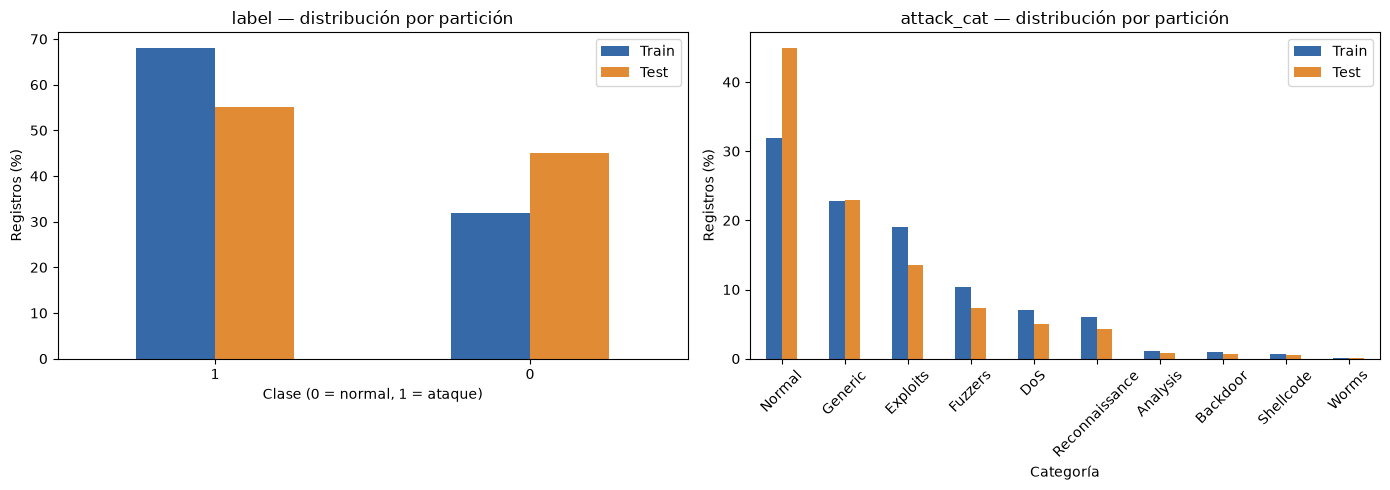

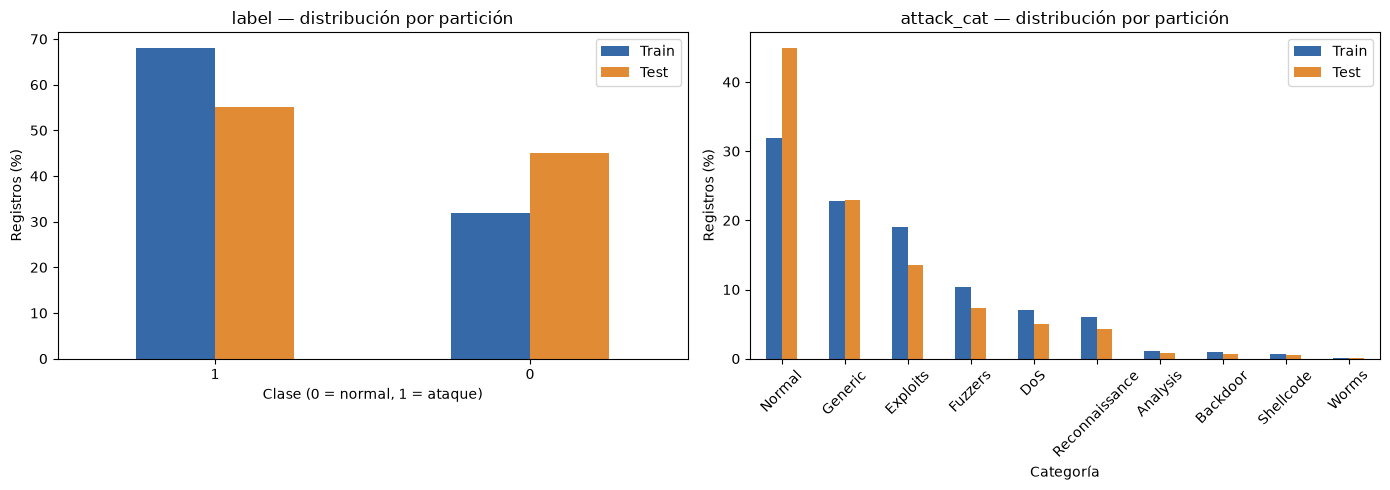

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_plot = label_distribution[["train_%", "test_%"]]
label_plot.plot(kind="bar", ax=axes[0], color=["#3569a8", "#e28b35"])
axes[0].set_title("label — distribución por partición")
axes[0].set_xlabel("Clase (0 = normal, 1 = ataque)")
axes[0].set_ylabel("Registros (%)")
axes[0].legend(["Train", "Test"])
axes[0].tick_params(axis="x", rotation=0)

attack_plot = attack_distribution[["train_%", "test_%"]]
attack_plot.plot(kind="bar", ax=axes[1], color=["#3569a8", "#e28b35"])
axes[1].set_title("attack_cat — distribución por partición")
axes[1].set_xlabel("Categoría")
axes[1].set_ylabel("Registros (%)")
axes[1].legend(["Train", "Test"])
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig


## Estadística descriptiva de variables numéricas

Se excluyen `id` y ambas etiquetas: la tabla describe las variables predictoras numéricas. El cálculo para describir datos se hace sobre train.

In [19]:
numeric_feature_cols = train_df.select_dtypes(include="number").columns.difference(
    [ID_COL, BINARY_TARGET]
).tolist()
# attack_cat suele ser texto; excluirla explícitamente mantiene claro el conjunto de predictores.
numeric_feature_cols = [
    col for col in numeric_feature_cols if col != MULTICLASS_TARGET
]
print(f"Cantidad de variables numéricas predictoras: {len(numeric_feature_cols)}")
print(train_df[numeric_feature_cols].describe().round(3).to_string())


Cantidad de variables numéricas predictoras: 39
           ackdat  ct_dst_ltm  ct_dst_sport_ltm  ct_dst_src_ltm  ct_flw_http_mthd  ct_ftp_cmd  ct_src_dport_ltm  ct_src_ltm  ct_srv_dst  ct_srv_src  ct_state_ttl        dbytes      dinpkt        djit         dload       dloss       dmean       dpkts         dtcpb        dttl         dur        dwin  is_ftp_login  is_sm_ips_ports         rate  response_body_len        sbytes      sinpkt         sjit         sload       sloss       smean       spkts         stcpb        sttl        swin      synack      tcprtt  trans_depth
count  175341.000  175341.000        175341.000      175341.000        175341.000  175341.000        175341.000  175341.000  175341.000  175341.000    175341.000  1.753410e+05  175341.000  175341.000  1.753410e+05  175341.000  175341.000  175341.000  1.753410e+05  175341.000  175341.000  175341.000    175341.000       175341.000   175341.000         175341.000  1.753410e+05  175341.000   175341.000  1.753410e+05  175341.0

## Variables categóricas

Para `proto`, `service` y `state` se informa la cantidad de valores distintos y los diez más frecuentes en cada partición.

In [20]:
for column in CATEGORICAL_COLS:
    print(f"### {column}")
    for split_name, dataframe in (("train", train_df), ("test", test_df)):
        frequencies = dataframe[column].value_counts(dropna=False)
        print(f"{split_name}: {dataframe[column].nunique(dropna=False)} valores distintos")
        print(frequencies.head(10).rename("filas").to_string())
        print()


### proto
train: 133 valores distintos
proto
tcp       79946
udp       63283
unas      12084
arp        2859
ospf       2595
sctp       1150
any         300
gre         225
sun-nd      201
swipe       201

test: 131 valores distintos
proto
tcp     43095
udp     29418
unas     3515
arp       987
ospf      676
sctp      324
any        96
gre        88
rsvp       64
ipv6       61

### service
train: 13 valores distintos
service
-           94168
dns         47294
http        18724
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80

test: 13 valores distintos
service
-           47153
dns         21367
http         8287
smtp         1851
ftp          1552
ftp-data     1396
pop3          423
ssh           204
ssl            30
snmp           29

### state
train: 9 valores distintos
state
INT    82275
FIN    77825
CON    13152
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1

test: 7 valor

## Valores de `state` presentes solo en test

Se identifican como control descriptivo de categorías no vistas entre particiones. Esta observación no se usa para ajustar el modelo en esta etapa.

In [21]:
states_train = set(train_df["state"].dropna().unique())
states_test = set(test_df["state"].dropna().unique())
print("Valores de state en test que no aparecen en train:")
print(sorted(states_test - states_train))


Valores de state en test que no aparecen en train:
['ACC', 'CLO']


## Filas duplicadas sin considerar `id`

Se cuentan por separado en cada partición, comparando todas las demás columnas.

In [22]:
columns_without_id = [column for column in train_df.columns if column != ID_COL]
train_duplicates = int(train_df.duplicated(subset=columns_without_id).sum())
test_duplicates = int(test_df.duplicated(subset=columns_without_id).sum())
print(f"Train: {train_duplicates:,} filas duplicadas")
print(f"Test:  {test_duplicates:,} filas duplicadas")


Train: 67,601 filas duplicadas
Test:  26,387 filas duplicadas


## Consistencia entre `label` y `attack_cat`

Se comprueba en cada partición que `label == 0` coincida exactamente con `attack_cat == "Normal"` en ambas direcciones.

In [23]:
for split_name, dataframe in (("train", train_df), ("test", test_df)):
    normal_by_label = dataframe[BINARY_TARGET].eq(0)
    normal_by_category = dataframe[MULTICLASS_TARGET].eq("Normal")
    inconsistencies = int((normal_by_label != normal_by_category).sum())
    print(f"{split_name}: {inconsistencies:,} filas inconsistentes")


train: 0 filas inconsistentes
test: 0 filas inconsistentes


## Relación entre `sttl` y `label` (solo train)

El cruce permite observar cómo se distribuyen las clases de `label` por valor de `sttl`. Se limita a train porque puede orientar el análisis del modelo.

In [24]:
sttl_label_counts = pd.crosstab(train_df["sttl"], train_df[BINARY_TARGET])
sttl_label_counts.columns = ["label_0_normal", "label_1_ataque"]
sttl_label_pct = pd.crosstab(
    train_df["sttl"], train_df[BINARY_TARGET], normalize="index"
).mul(100).round(2)
sttl_label_pct.columns = ["label_0_normal_%", "label_1_ataque_%"]
sttl_summary = sttl_label_counts.join(sttl_label_pct)
print(sttl_summary.to_string())


      label_0_normal  label_1_ataque  label_0_normal_%  label_1_ataque_%
sttl                                                                    
0               2859             303             90.42              9.58
1                 64               0            100.00              0.00
29                 2               0            100.00              0.00
31             39455               0            100.00              0.00
60                 6               0            100.00              0.00
62              2167           15514             12.26             87.74
63                32               0            100.00              0.00
64               181               0            100.00              0.00
252                2               0            100.00              0.00
254            11230          103513              9.79             90.21
255                2              11             15.38             84.62


## Columnas que no entran al modelo

- `id` no representa una característica del flujo: funciona como índice y se descarta.
- En la tarea binaria, `attack_cat` se excluye de las entradas para que el modelo no vea la respuesta alternativa.
- En la tarea multiclase, `label` se excluye de las entradas por el mismo motivo.

Las columnas objetivo se conservan como etiquetas según la tarea. Las decisiones de modelado se basarán en train; el test oficial se reservará para la evaluación final única.
